# **1. Introduction**

This is my individual notebook for the group project. This notebook focuses on forecasting monthly car sales using the ARIMA model.

The data cleaning, preparation and EDA were completed in the group notebook. In this notebook, I use the cleaned dataset and the same train-test split agreed by the group.

I chose ARIMA because it is a classical time series model and it can model trend and past sales behaviour after differencing. ARIMA does not directly model seasonality, so it is useful as a non-seasonal model to compare with SARIMA.

The aim is to forecast the final 12 months of sales, compare the ARIMA forecast with a naive baseline, and evaluate the result using MAE and RMSE.

GitHub Repository link: https://github.com/RAJDONDA89/Group-project_-Advance-Forecasting.git

# **2. Import Libraries**

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# **3. Load Dataset**



In [11]:
url = 'https://raw.githubusercontent.com/RAJDONDA89/Group-project_-Advance-Forecasting/refs/heads/main/Data/cleaned_sales_data.csv'

df = pd.read_csv(url)
df.columns = ["Date", "Sales"]
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
df.head()

,Sales
Date,
1960-01-01,6550
1960-02-01,8728
1960-03-01,12026
1960-04-01,14395
1960-05-01,14587


The dataset was imported from the group github repository, the date column is converted into datetime format and set as index to use data for timeseries forecasting.

In [12]:

df.info()
print("\n")

df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 108 entries, 1960-01-01 to 1968-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sales   108 non-null    int64
dtypes: int64(1)
memory usage: 1.7 KB




,Sales
count,108.000000
mean,14595.111111
std,4525.213913
min,5568.000000
25%,11391.250000
50%,14076.000000
75%,17595.750000
max,26099.000000


# **4. Train/Test Split**



In [13]:
train = df[:-12]
test = df[-12:]

The same train-test split from the group notebook is used here. The final 12 months are used as the test set, while all earlier observations are used for training.

This keeps the evaluation fair because all group members use the same testing period.

# **5. Baseline Model**




A naive forecast is used as the baseline model. This method assumes that the next value will be the same as the last observed training value.

This baseline is simple, but it is useful because the ARIMA model should perform better than this basic method to justify its use.

In [48]:
naive_forecast = pd.Series(train["Sales"].iloc[-1], index=test.index)

mae_naive = mean_absolute_error(test["Sales"], naive_forecast)
rmse_naive = np.sqrt(mean_squared_error(test["Sales"], naive_forecast))

print("Naive MAE:", round(mae_naive, 2))
print("Naive RMSE:", round(rmse_naive, 2))

Naive MAE: 4599.0
Naive RMSE: 5865.37


# **6. Tuning & Stationarity Test**

ARIMA models work better when the time series is stationary. A stationary series has a more stable mean and variance over time.

The Augmented Dickey-Fuller test is used to check whether the training series is stationary. If the p-value is greater than 0.05, differencing is needed.

## **6.1 ADF Test**


In [28]:
adf_result = adfuller(train["Sales"])

print("ADF Statistic:", round(adf_result[0], 4))
print("p-value:", round(adf_result[1], 4))

for key, value in adf_result[4].items():
    print(f"Critical Value {key}: {round(value, 4)}")

ADF Statistic: -1.6886
p-value: 0.437
Critical Value 1%: -3.5117
Critical Value 5%: -2.897
Critical Value 10%: -2.5857


The original series is not fully stable, so first differencing is applied. This means the model looks at the change from one month to the next instead of the original sales values.

Differencing helps make the series more suitable for ARIMA modelling.

## **6.2 Differencing**

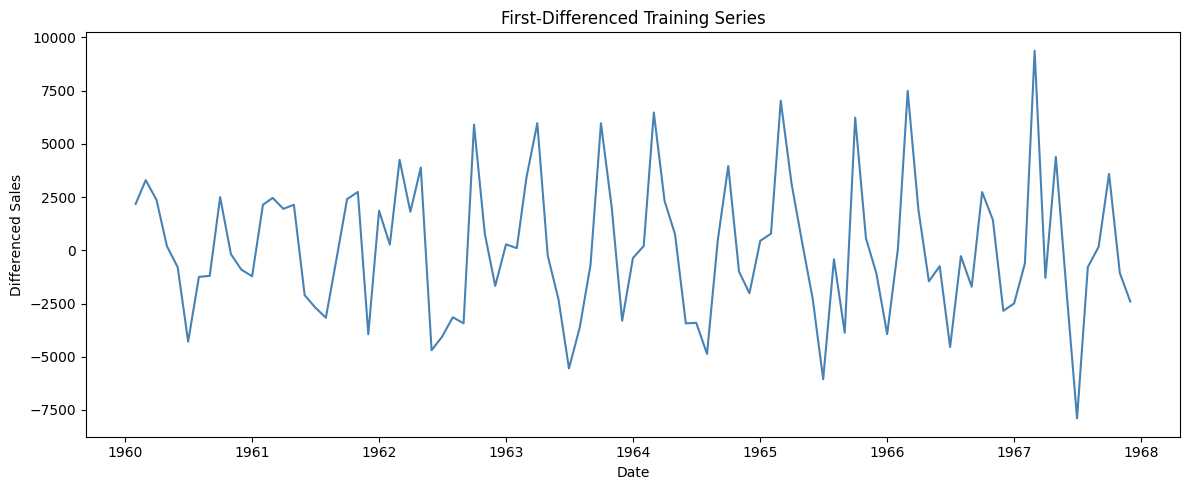

ADF Statistic after differencing: -3.623
p-value after differencing: 0.0053


In [31]:
train_diff = train["Sales"].diff().dropna()

plt.figure(figsize=(12, 5))
plt.plot(train_diff, color="steelblue")
plt.title("First-Differenced Training Series")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")
plt.tight_layout()
plt.show()

adf_diff = adfuller(train_diff)

print("ADF Statistic after differencing:", round(adf_diff[0], 4))
print("p-value after differencing:", round(adf_diff[1], 4))

## **6.3 Hyperparameter Tuning**

Different ARIMA parameter combinations are tested to find a suitable model.

The ARIMA parameters are p, d and q. The value of d is set to 1 because the stationarity check showed that differencing was needed. The best model is selected using AIC, where a lower AIC means a better balance between model fit and complexity.

In [40]:
orders = [(1,1,1), (1,1,2), (2,1,1), (2,1,2)]
results = []

for order in orders:
    try:
        model = ARIMA(train["Sales"], order=order)
        fitted = model.fit()
        results.append((order, fitted.aic))
        print(f"ARIMA{order} AIC:", round(fitted.aic, 2))
    except Exception as e:
        print(f"ARIMA{order} failed:", e)

best_order = min(results, key=lambda x: x[1])[0]
print("Best ARIMA order:", best_order)

ARIMA(1, 1, 1) AIC: 1802.38
ARIMA(1, 1, 2) AIC: 1795.57
ARIMA(2, 1, 1) AIC: 1784.6
ARIMA(2, 1, 2) AIC: 1771.86
Best ARIMA order: (2, 1, 2)




The results show that different parameter combinations lead to different AIC values.The ARIMA(2,1,2) model was selected because it produced the lowest AIC value among the tested configurations. This shows that the final model was chosen through a systematic tuning process rather than a single arbitrary run.

# **7. ARIMA Model**

In [38]:
arima_model = ARIMA(train["Sales"], order=best_order)
arima_fitted = arima_model.fit()

forecast_arima = arima_fitted.forecast(steps=len(test))
forecast_arima

,predicted_mean
1968-01-01,11166.142128
1968-02-01,10904.719654
1968-03-01,13166.650421
1968-04-01,15624.909424
1968-05-01,15781.147774
1968-06-01,13504.445665
1968-07-01,11135.737566
1968-08-01,11081.191117
1968-09-01,13368.327411
1968-10-01,15646.716407


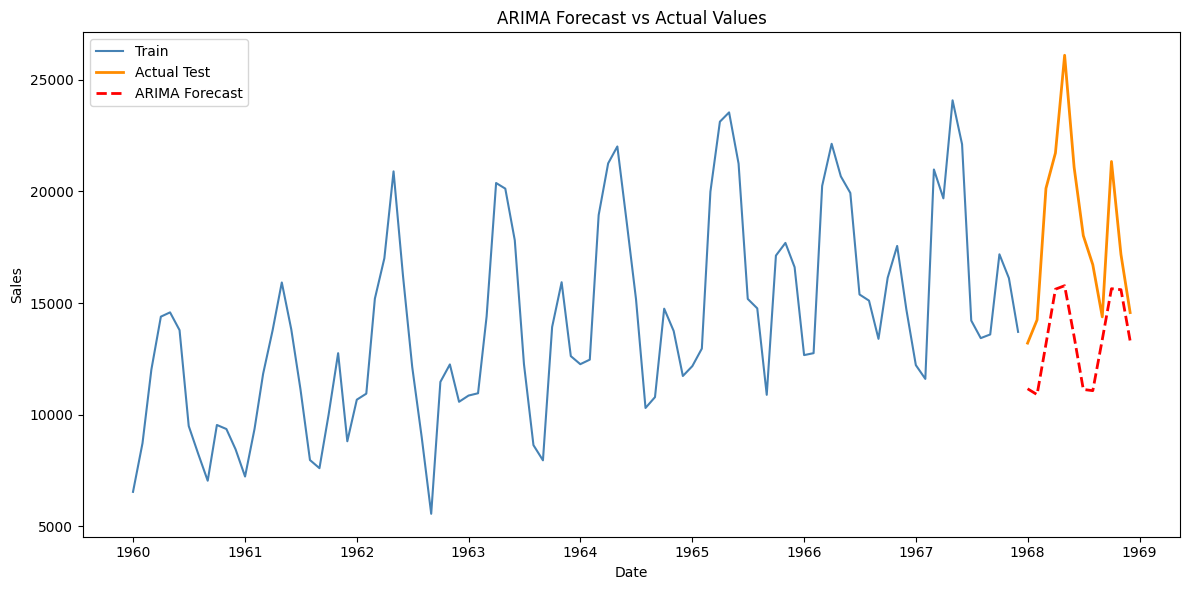

In [42]:
plt.figure(figsize=(12, 6))

plt.plot(train.index, train["Sales"], label="Train", color="steelblue")
plt.plot(test.index, test["Sales"], label="Actual Test", color="darkorange", linewidth=2)
plt.plot(test.index, forecast_arima, label="ARIMA Forecast", color="red", linestyle="--", linewidth=2)

plt.title("ARIMA Forecast vs Actual Values")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

# **8. Model Evaluation**

The ARIMA forecast is evaluated using MAE and RMSE. The same metrics are used for the naive baseline so both methods can be compared fairly.

In [43]:
mae_arima = mean_absolute_error(test["Sales"], forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test["Sales"], forecast_arima))

print("ARIMA MAE:", round(mae_arima, 2))
print("ARIMA RMSE:", round(rmse_arima, 2))

ARIMA MAE: 4870.43
ARIMA RMSE: 5641.64


In [44]:
comparison = pd.DataFrame({
    "Model": ["Naive Baseline", "ARIMA"],
    "MAE": [mae_naive, mae_arima],
    "RMSE": [rmse_naive, rmse_arima]
})

comparison

,Model,MAE,RMSE
0,Naive Baseline,4599.000000,5865.373830
1,ARIMA,4870.430467,5641.636366


The ARIMA model is compared against the naive baseline. If ARIMA has lower MAE and RMSE, it means the model improves forecasting accuracy compared with simply repeating the last observed value.

Even if ARIMA improves the baseline, the forecast may still be smoother than the actual values because ARIMA does not directly model seasonal patterns.

# **9. Discussion**

The ARIMA model is useful because it is simple, interpretable and suitable for univariate time series forecasting. It can capture trend and short-term relationships after differencing.

However, the monthly car sales data shows seasonal behaviour in the group EDA notebook. ARIMA does not directly include seasonal terms, so it may not capture all repeating monthly patterns. This is why SARIMA may perform better for this dataset.

In terms of computation, ARIMA is not very heavy for this dataset. It runs quickly and is easier to explain compared with deep learning models. The main limitation is that the data is quite small and seasonal, which can reduce the stability of ARIMA forecasts.

# **10. Reflection**

The ARIMA model demonstrates the usefulness of classical statistical methods for forecasting time series data.

However, selecting appropriate parameters requires experimentation and understanding of the data. The tuning process highlights the importance of systematic evaluation rather than relying on a single model.

The main limitation of ARIMA is its inability to explicitly capture seasonality. This highlights the importance of choosing models based on dataset characteristics rather than complexity alone.

# **11. Conclusion**

This notebook implemented one naive baseline and one ARIMA forecasting model for monthly car sales.

The ARIMA model was tuned using AIC and evaluated using MAE and RMSE. The results were compared with the naive baseline to check whether ARIMA improved forecasting performance.

Overall, ARIMA is a useful classical forecasting model, but its main weakness is that it does not directly model seasonality. Therefore, it works well as a benchmark model, while SARIMA is expected to be more suitable for this seasonal dataset.

# **12. AI declaration**
AI tools were used to support coding, debugging and explanation writing during this notebook. The final code, results and interpretation were reviewed and adjusted before submission.